# Appendix D — Probability Distributions: Theory Meets Computation

**STAT 418 · Computational Data Science** · runnable companion to the
[Probability Distributions appendix](../../Website/appendices/probability_review.rst).

Abstract foundations (Kolmogorov's axioms, random variables, PMFs/PDFs/CDFs) don't
by themselves solve data problems. In practice we recognize *patterns*: arrivals look
one way, failures another, measurement errors a third. Those recurring patterns are
captured by **families of probability distributions** — parametric models that have
been studied, catalogued, and implemented. This notebook makes each one *concrete*:
we draw samples, overlay the theoretical law on the simulation, confirm the moments,
and demonstrate the relationships (limits, sums, transformations) that tie the whole
family tree together.

> De Moivre's 1733 insight — that the jagged binomial histogram smooths into a bell
> curve as the number of flips grows — is the prototype for everything here: random
> mechanisms produce *regular*, computable laws. We will reproduce that convergence,
> and many more, by simulation.

## Learning outcomes
By the end you can:
1. Use the unified `scipy.stats` interface (`.pmf`/`.pdf`, `.cdf`, `.ppf`, `.rvs`,
   `.mean`, `.var`) for any distribution, and know when `random`, `numpy`, or `scipy`
   is the right tool.
2. For each major distribution, **sample it, overlay the theory, and verify the
   mean/variance** against the closed form.
3. Demonstrate the **limit theorems** (De Moivre–Laplace, Poisson limit, CLT,
   $t\to\mathcal N$) by simulation.
4. Demonstrate the **structural relationships**: sums of Bernoullis $\to$ Binomial,
   sums of Exponentials $\to$ Gamma, squared Normals $\to$ $\chi^2$, ratios of
   $\chi^2$ $\to$ $F$, order statistics of Uniforms $\to$ Beta, and the memoryless
   property of the Exponential / Geometric.

## Section map
| Group | Distributions (each: PMF/PDF · sample · theory-vs-sim · relationship) |
|-------|----------------------------------------------------------------------|
| Tooling | the `scipy.stats` interface; `random` vs `numpy` vs `scipy` |
| Discrete | Bernoulli · Binomial · Poisson (+ Poisson-limit) · Geometric · Negative Binomial |
| Continuous | Uniform · Normal · Exponential · Gamma · Beta |
| Inference | Student's $t$ · Chi-square · $F$ |
| Wrap-up | relationship map · selection guide · exercises (Poisson-limit GOF, memorylessness) |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import gamma as gamma_fn
import math, time
%matplotlib inline

# Reproducibility (STYLE.md contract): one Generator + a legacy seed for any
# scipy .rvs calls that read the global state.
rng = np.random.default_rng(418)
np.random.seed(418)

plt.rcParams.update({
    'figure.figsize': (7.2, 4.2), 'figure.dpi': 110,
    'axes.grid': True, 'grid.alpha': 0.25,
    'axes.spines.top': False, 'axes.spines.right': False,
    'font.size': 11,
})
BLUE, RED, GREEN, ORANGE, PURPLE = '#4C72B0', '#C44E52', '#55A868', '#DD8452', '#8172B3'

def compare(name, theo_mean, theo_var, samples):
    '''Print theoretical vs. empirical mean/variance for a simulated sample.'''
    m, v = float(np.mean(samples)), float(np.var(samples))
    print(f'{name}  (n = {len(samples):,})')
    print(f'  mean      theory {theo_mean:10.4f}   sample {m:10.4f}')
    print(f'  variance  theory {theo_var:10.4f}   sample {v:10.4f}')

print('environment ready · numpy', np.__version__)
print('Gamma(1/2) = sqrt(pi) =', round(gamma_fn(0.5), 6))


environment ready · numpy 1.26.4
Gamma(1/2) = sqrt(pi) = 1.772454


## The Python toolbox for probability

Three libraries cover almost everything. **`random`** (built in) is fine for teaching
and one-off scalars. **`numpy.random`** is *vectorized* — your workhorse for
simulation. **`scipy.stats`** is the full toolkit: every distribution exposes the same
methods, so once you learn the interface you know them all:

| call | meaning |
|------|---------|
| `dist.pmf(k)` / `dist.pdf(x)` | probability mass (discrete) / density (continuous) |
| `dist.cdf(x)` | $P(X\le x)$ |
| `dist.ppf(q)` | quantile / inverse-CDF: the $x$ with $P(X\le x)=q$ |
| `dist.rvs(size, random_state)` | random samples |
| `dist.mean()`, `dist.var()`, `dist.std()` | moments, in closed form |

First, *why* we vectorize — the speed gap between a Python loop and NumPy is enormous.


In [2]:
# Why vectorize: Python-loop sampling vs. NumPy on the same task.
n = 1_000_000
import random as _random
t0 = time.perf_counter(); _ = [_random.random() for _ in range(n)]; py = time.perf_counter() - t0
t0 = time.perf_counter(); _ = rng.random(n);                        nz = time.perf_counter() - t0
print(f'Drawing {n:,} Uniform(0,1) values:')
print(f'  python random loop : {py:.4f} s')
print(f'  numpy (vectorized) : {nz:.4f} s')
print(f'  -> numpy is ~{py/nz:.0f}x faster (the reason every simulation below is vectorized)')


Drawing 1,000,000 Uniform(0,1) values:
  python random loop : 0.0648 s
  numpy (vectorized) : 0.0114 s
  -> numpy is ~6x faster (the reason every simulation below is vectorized)


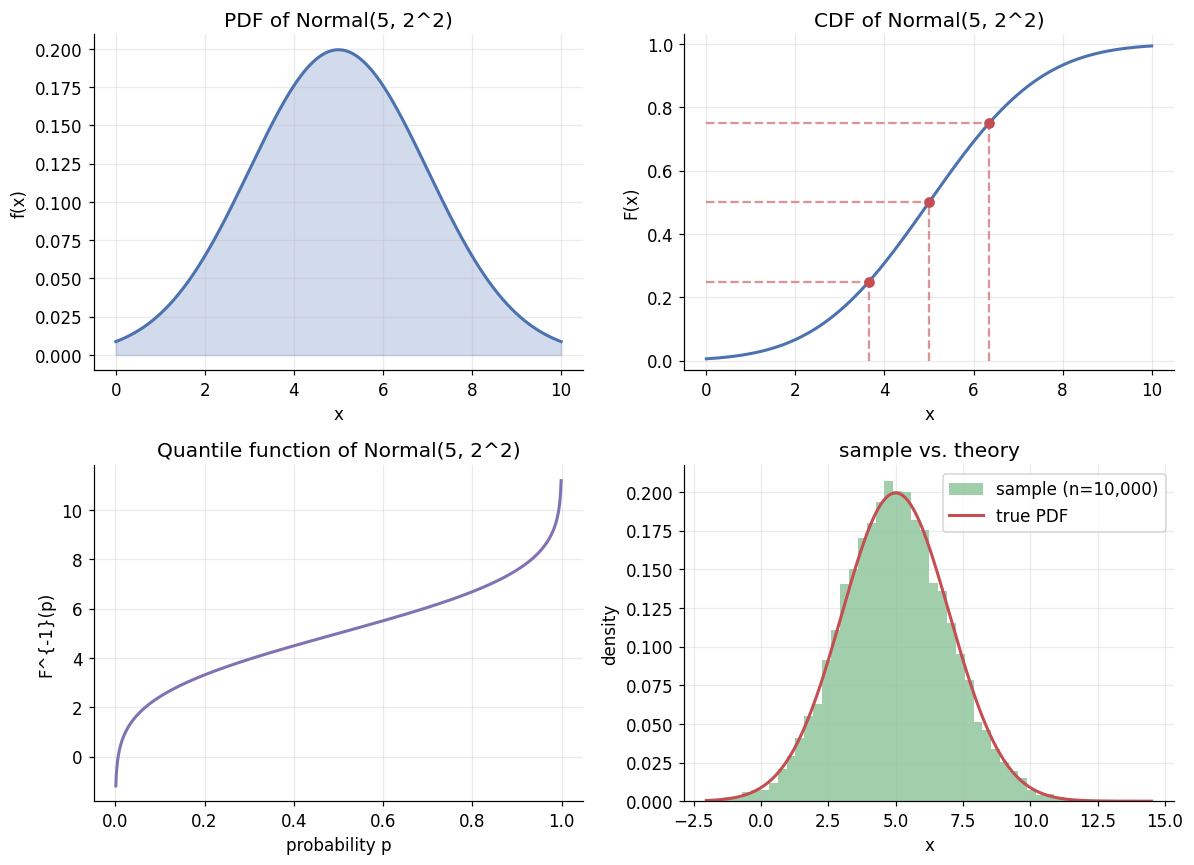

Normal(5, 2^2):  mean 5.0000   var 4.0000   std 2.0000
  median 5.0000   Q1 3.6510   Q3 6.3490   IQR 2.6980


In [3]:
# One interface, every distribution. A compact 'analyze' helper that draws the four
# faces of a distribution -- PMF/PDF, CDF, quantile function, and a sampled histogram
# with the true law overlaid -- and prints the closed-form summary.
def analyze_distribution(dist, name, x_range, discrete=False):
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 8))
    x = np.linspace(x_range[0], x_range[1], 1000)

    if discrete:
        xk = np.arange(int(x_range[0]), int(x_range[1]) + 1)
        ax1.stem(xk, dist.pmf(xk), basefmt=' ', linefmt=BLUE, markerfmt='o')
        ax1.set_ylabel('P(X = k)'); ax1.set_title(f'PMF of {name}')
    else:
        ax1.plot(x, dist.pdf(x), color=BLUE, lw=2)
        ax1.fill_between(x, 0, dist.pdf(x), color=BLUE, alpha=0.25)
        ax1.set_ylabel('f(x)'); ax1.set_title(f'PDF of {name}')
    ax1.set_xlabel('x')

    ax2.plot(x, dist.cdf(x), color=BLUE, lw=2)
    for q in (0.25, 0.5, 0.75):
        xq = dist.ppf(q)
        ax2.plot([xq, xq], [0, q], '--', color=RED, alpha=0.6)
        ax2.plot([x_range[0], xq], [q, q], '--', color=RED, alpha=0.6)
        ax2.plot(xq, q, 'o', color=RED)
    ax2.set_xlabel('x'); ax2.set_ylabel('F(x)'); ax2.set_title(f'CDF of {name}')
    ax2.set_ylim(-0.03, 1.03)

    p = np.linspace(0.001, 0.999, 1000)
    ax3.plot(p, dist.ppf(p), color=PURPLE, lw=2)
    ax3.set_xlabel('probability p'); ax3.set_ylabel('F^{-1}(p)')
    ax3.set_title(f'Quantile function of {name}')

    s = dist.rvs(size=10000, random_state=418)
    ax4.hist(s, bins=50, density=True, alpha=0.55, color=GREEN, label='sample (n=10,000)')
    if discrete:
        xp = np.arange(int(s.min()), int(s.max()) + 1)
        ax4.plot(xp, dist.pmf(xp), 'o-', color=RED, lw=2, label='true PMF')
    else:
        xp = np.linspace(s.min(), s.max(), 200)
        ax4.plot(xp, dist.pdf(xp), color=RED, lw=2, label='true PDF')
    ax4.set_xlabel('x'); ax4.set_ylabel('density'); ax4.set_title('sample vs. theory'); ax4.legend()
    plt.tight_layout(); plt.show()

    print(f'{name}:  mean {dist.mean():.4f}   var {dist.var():.4f}   std {dist.std():.4f}')
    print(f'  median {dist.ppf(0.5):.4f}   Q1 {dist.ppf(0.25):.4f}   Q3 {dist.ppf(0.75):.4f}'
          f'   IQR {dist.ppf(0.75) - dist.ppf(0.25):.4f}')

analyze_distribution(stats.norm(loc=5, scale=2), 'Normal(5, 2^2)', (0, 10))


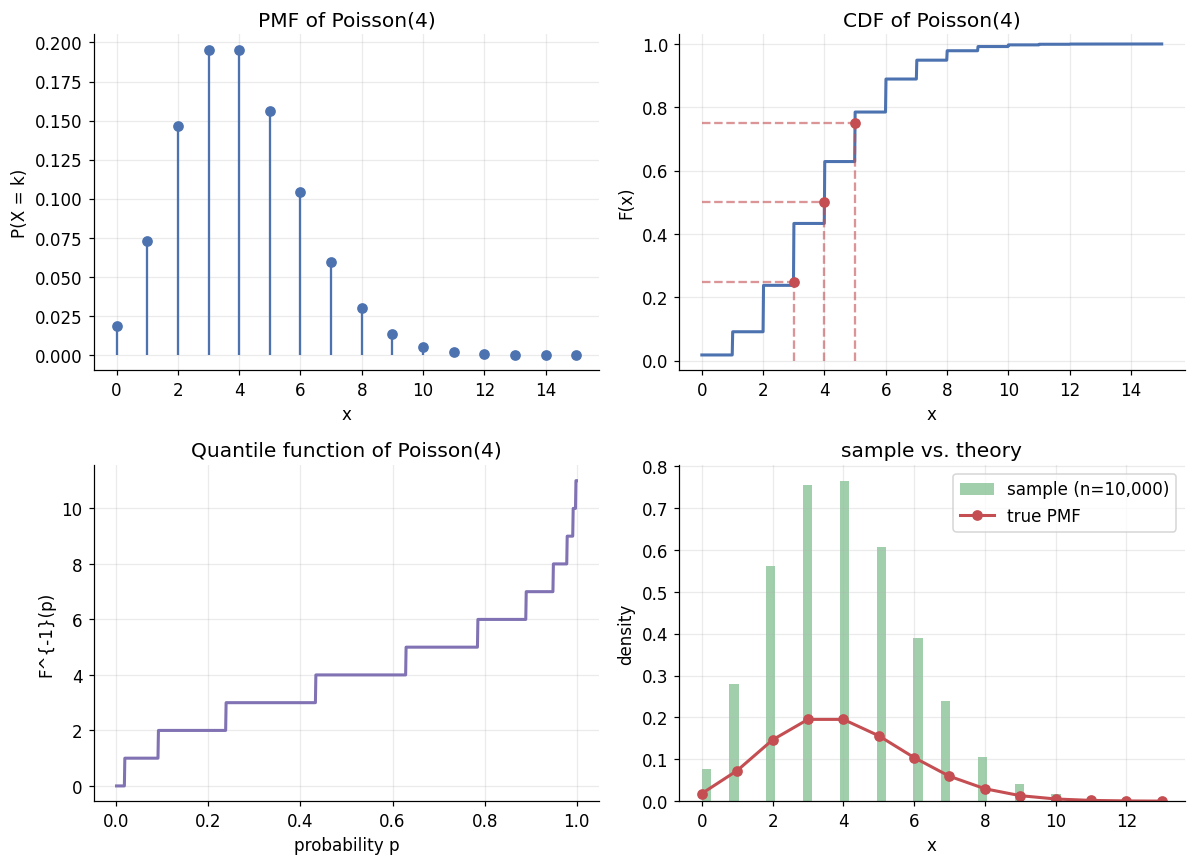

Poisson(4):  mean 4.0000   var 4.0000   std 2.0000
  median 4.0000   Q1 3.0000   Q3 5.0000   IQR 2.0000


In [4]:
# The exact same interface for a DISCRETE law -- nothing changes but .pmf vs .pdf.
analyze_distribution(stats.poisson(mu=4), 'Poisson(4)', (0, 15), discrete=True)


## Discrete distributions

### Bernoulli — a single binary trial

$X\sim\text{Bernoulli}(p)$ takes value $1$ ("success") with probability $p$ and $0$
otherwise: $P(X=k)=p^{k}(1-p)^{1-k}$, $k\in\{0,1\}$.

- **Mean** $\mathbb E[X]=p$ · **Variance** $\mathrm{Var}(X)=p(1-p)$ (maximized at $p=0.5$).

Named for Jacob Bernoulli (*Ars Conjectandi*, 1713), who proved the first **law of
large numbers**: the observed success frequency converges to $p$. We reproduce exactly
that — the running mean of Bernoulli draws homing in on the truth.


In [5]:
p = 0.7
draws = rng.binomial(1, p, 100_000)          # Bernoulli(p) == Binomial(1, p)
compare(f'Bernoulli({p})', p, p*(1-p), draws)
print(f'  P(X=0) = {stats.bernoulli.pmf(0, p):.3f}   P(X=1) = {stats.bernoulli.pmf(1, p):.3f}')


Bernoulli(0.7)  (n = 100,000)
  mean      theory     0.7000   sample     0.7013
  variance  theory     0.2100   sample     0.2095
  P(X=0) = 0.300   P(X=1) = 0.700


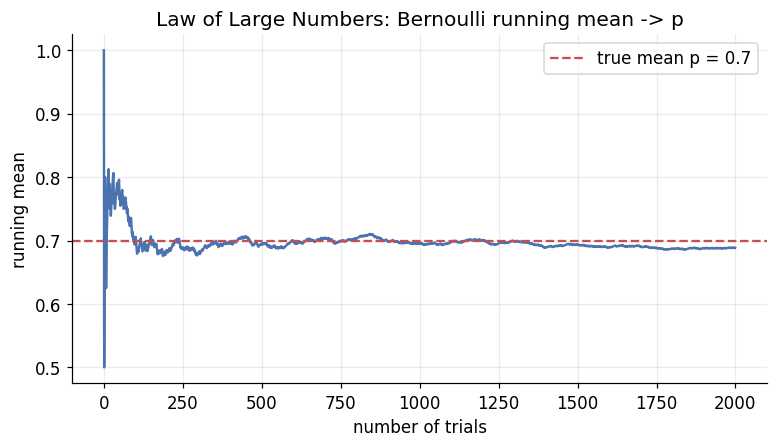

running mean after 2000 trials = 0.6885  (target 0.7)


In [6]:
# Law of Large Numbers: the running mean converges to p.
trials = rng.binomial(1, p, 2000)
running = np.cumsum(trials) / np.arange(1, len(trials) + 1)
fig, ax = plt.subplots()
ax.plot(running, color=BLUE, lw=1.6)
ax.axhline(p, color=RED, ls='--', lw=1.5, label=f'true mean p = {p}')
ax.set_xlabel('number of trials'); ax.set_ylabel('running mean')
ax.set_title('Law of Large Numbers: Bernoulli running mean -> p')
ax.legend(); plt.tight_layout(); plt.show()
print(f'running mean after {len(trials)} trials = {running[-1]:.4f}  (target {p})')


### Binomial — number of successes in $n$ trials

$X=\sum_{i=1}^n X_i$ with $X_i\sim\text{Bernoulli}(p)$ i.i.d., so
$P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}$.

- **Mean** $np$ · **Variance** $np(1-p)$.
- **Sum of Bernoullis** (MGF: $[(1-p)+pe^t]^n$).
- **De Moivre–Laplace:** $\dfrac{X-np}{\sqrt{np(1-p)}}\xrightarrow{d}\mathcal N(0,1)$ —
  the bell curve emerging from coin flips, the first limit theorem in probability.


In [7]:
n_b, p_b = 20, 0.3
samp = rng.binomial(n_b, p_b, 10000)
compare(f'Binomial({n_b}, {p_b})', n_b*p_b, n_b*p_b*(1-p_b), samp)
mode = int((n_b + 1) * p_b)
print(f'  mode = floor((n+1)p) = {mode}   P(X=mode) = {stats.binom.pmf(mode, n_b, p_b):.4f}')
print(f'  P(X <= 6) = {stats.binom.cdf(6, n_b, p_b):.4f}')


Binomial(20, 0.3)  (n = 10,000)
  mean      theory     6.0000   sample     5.9650
  variance  theory     4.2000   sample     4.1800
  mode = floor((n+1)p) = 6   P(X=mode) = 0.1916
  P(X <= 6) = 0.6080


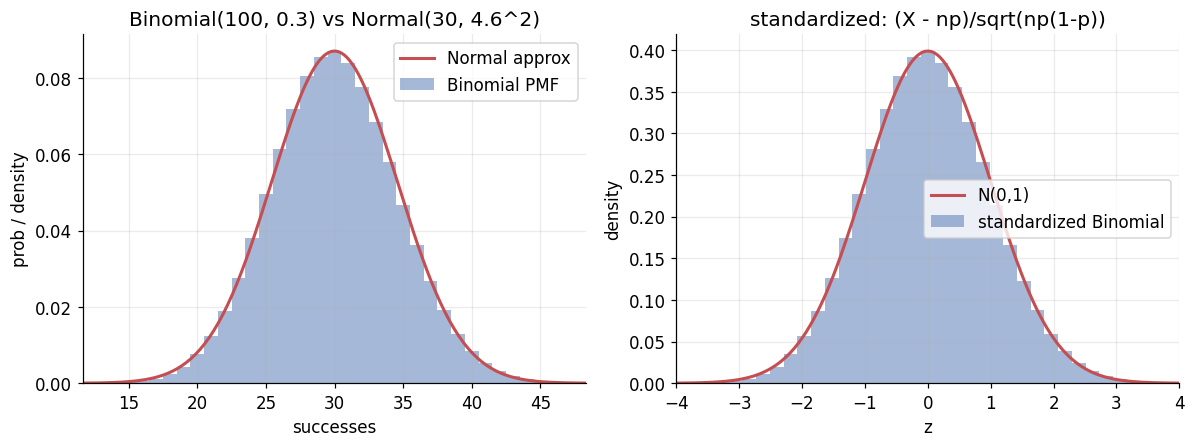

In [8]:
# De Moivre-Laplace: Binomial(n, p) -> Normal(np, np(1-p)) as n grows.
n_dm, p_dm = 100, 0.3
mu, sigma = n_dm*p_dm, np.sqrt(n_dm*p_dm*(1-p_dm))
k = np.arange(0, n_dm + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
ax1.bar(k, stats.binom.pmf(k, n_dm, p_dm), alpha=0.5, color=BLUE, width=1.0, label='Binomial PMF')
xx = np.linspace(0, n_dm, 600)
ax1.plot(xx, stats.norm.pdf(xx, mu, sigma), color=RED, lw=2, label='Normal approx')
ax1.set_xlim(mu - 4*sigma, mu + 4*sigma); ax1.legend()
ax1.set_xlabel('successes'); ax1.set_ylabel('prob / density')
ax1.set_title(f'Binomial({n_dm}, {p_dm}) vs Normal({mu:.0f}, {sigma:.1f}^2)')
# standardized overlay
z = (k - mu) / sigma
ax2.bar(z, stats.binom.pmf(k, n_dm, p_dm) * sigma, alpha=0.5, color=BLUE, width=1/sigma,
        label='standardized Binomial')
zz = np.linspace(-4, 4, 400)
ax2.plot(zz, stats.norm.pdf(zz), color=RED, lw=2, label='N(0,1)')
ax2.set_xlim(-4, 4); ax2.legend(); ax2.set_xlabel('z'); ax2.set_ylabel('density')
ax2.set_title('standardized: (X - np)/sqrt(np(1-p))')
plt.tight_layout(); plt.show()


### Poisson — counts of rare events at rate $\lambda$

$P(X=k)=\dfrac{\lambda^k e^{-\lambda}}{k!}$, the law of events in a fixed interval at
constant rate $\lambda$ (Poisson 1837; Bortkiewicz's Prussian horse-kick deaths, 1898).

- **Mean $=$ Variance $=\lambda$** — its signature; the *index of dispersion*
  $\mathrm{Var}/\mathrm{mean}$ should sit at $1$.
- **Poisson limit theorem:** $\text{Binomial}(n,\lambda/n)\to\text{Poisson}(\lambda)$ as
  $n\to\infty$ — "many trials, tiny per-trial probability, fixed expected count."


In [9]:
lam = 4
samp = rng.poisson(lam, 10000)
compare(f'Poisson({lam})', lam, lam, samp)
print(f'  index of dispersion var/mean = {np.var(samp)/np.mean(samp):.3f}  (Poisson -> 1)')


Poisson(4)  (n = 10,000)
  mean      theory     4.0000   sample     3.9794
  variance  theory     4.0000   sample     4.0352
  index of dispersion var/mean = 1.014  (Poisson -> 1)


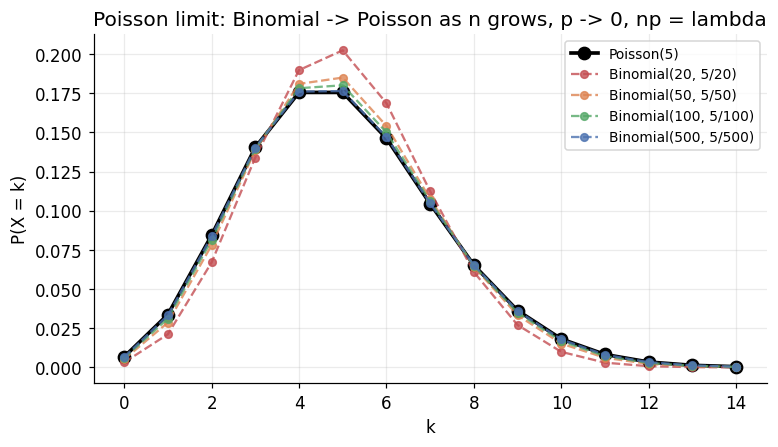

Binomial(n, 5/n) variance/mean ratio = 1 - lambda/n:
  n =   20:  1 - 5/20 = 0.7500
  n =   50:  1 - 5/50 = 0.9000
  n =  100:  1 - 5/100 = 0.9500
  n =  500:  1 - 5/500 = 0.9900


In [10]:
# Poisson limit theorem: Binomial(n, lambda/n) PMF converges to Poisson(lambda).
lam = 5
kk = np.arange(0, 15)
fig, ax = plt.subplots()
ax.plot(kk, stats.poisson.pmf(kk, lam), 'o-', color='k', lw=2.4, ms=8, label=f'Poisson({lam})')
for n_, col in zip([20, 50, 100, 500], [RED, ORANGE, GREEN, BLUE]):
    ax.plot(kk, stats.binom.pmf(kk, n_, lam/n_), 'o--', color=col, alpha=0.8, ms=5,
            label=f'Binomial({n_}, {lam}/{n_})')
ax.set_xlabel('k'); ax.set_ylabel('P(X = k)')
ax.set_title('Poisson limit: Binomial -> Poisson as n grows, p -> 0, np = lambda')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()
# numeric convergence of the var/mean ratio (= 1 - lambda/n)
print('Binomial(n, 5/n) variance/mean ratio = 1 - lambda/n:')
for n_ in [20, 50, 100, 500]:
    print(f'  n = {n_:4d}:  1 - {lam}/{n_} = {1 - lam/n_:.4f}')


### Geometric — trials until the first success

SciPy/NumPy convention: $X=$ number of trials up to and including the first success,
support $\{1,2,3,\dots\}$, $P(X=k)=(1-p)^{k-1}p$.

- **Mean** $1/p$ · **Variance** $(1-p)/p^2$ · **Survival** $P(X>k)=(1-p)^k$.
- **Memoryless (the only discrete law that is):**
  $P(X>s+t\mid X>s)=P(X>t)$ — past failures carry no information about the future.


In [11]:
pg = 0.3
g = rng.geometric(pg, 100_000)
compare(f'Geometric({pg})', 1/pg, (1-pg)/pg**2, g)
# Memoryless check: P(X > s+t | X > s) should equal P(X > t).
s, t = 5, 3
surv_s = g[g > s]
cond = np.mean(surv_s > s + t)
print(f'  P(X > {t})            = {np.mean(g > t):.4f}')
print(f'  P(X > {s+t} | X > {s})    = {cond:.4f}   theory (1-p)^t = {(1-pg)**t:.4f}')


Geometric(0.3)  (n = 100,000)
  mean      theory     3.3333   sample     3.3432
  variance  theory     7.7778   sample     7.8494
  P(X > 3)            = 0.3445
  P(X > 8 | X > 5)    = 0.3432   theory (1-p)^t = 0.3430


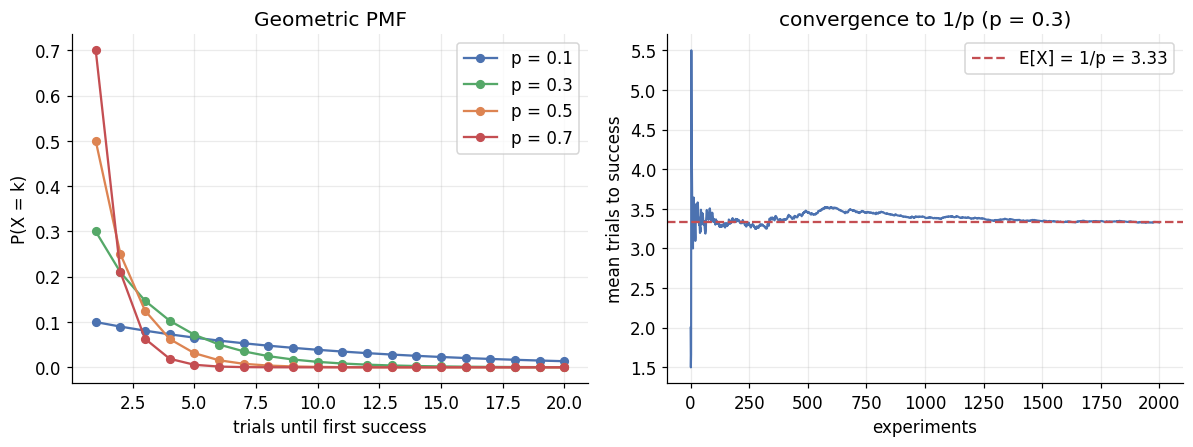

In [12]:
# PMF for several p, and convergence of the running mean to 1/p.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2))
kk = np.arange(1, 21)
for pv, col in zip([0.1, 0.3, 0.5, 0.7], [BLUE, GREEN, ORANGE, RED]):
    ax1.plot(kk, stats.geom.pmf(kk, pv), 'o-', color=col, ms=5, label=f'p = {pv}')
ax1.set_xlabel('trials until first success'); ax1.set_ylabel('P(X = k)')
ax1.set_title('Geometric PMF'); ax1.legend()
samp = rng.geometric(pg, 2000)
run = np.cumsum(samp) / np.arange(1, len(samp) + 1)
ax2.plot(run, color=BLUE, lw=1.4)
ax2.axhline(1/pg, color=RED, ls='--', lw=1.5, label=f'E[X] = 1/p = {1/pg:.2f}')
ax2.set_xlabel('experiments'); ax2.set_ylabel('mean trials to success')
ax2.set_title(f'convergence to 1/p (p = {pg})'); ax2.legend()
plt.tight_layout(); plt.show()


### Negative Binomial — failures before the $r$-th success

$X\sim\text{NegBinomial}(r,p)$ counts failures before the $r$-th success,
$P(X=k)=\binom{k+r-1}{k}p^r(1-p)^k$.

- **Mean** $\dfrac{r(1-p)}{p}$ · **Variance** $\dfrac{r(1-p)}{p^2}$ — note
  $\mathrm{Var}>\mathrm{mean}$: **overdispersion**, the cure for count data too wild
  for Poisson.
- **Sum of geometrics:** $\sum_{i=1}^r Y_i - r$ with $Y_i\sim\text{Geometric}(p)$.
- **Gamma–Poisson mixture:** a Poisson whose rate is itself Gamma-distributed.


In [13]:
# Overdispersion: Poisson and Negative Binomial with the SAME mean (=10).
mean_val, r = 10, 5
p_nb = r / (r + mean_val)                  # gives mean r(1-p)/p = 10
pois = rng.poisson(mean_val, 10000)
nb = stats.nbinom.rvs(r, p_nb, size=10000, random_state=418)
print(f'Poisson(10):           mean {pois.mean():.2f}  var {pois.var():.2f}  var/mean {pois.var()/pois.mean():.2f}')
print(f'NegBinom(r=5, p={p_nb:.3f}): mean {nb.mean():.2f}  var {nb.var():.2f}  var/mean {nb.var()/nb.mean():.2f}')
print(f'  NB theory: mean {r*(1-p_nb)/p_nb:.2f}   var {r*(1-p_nb)/p_nb**2:.2f}  (var > mean = overdispersed)')


Poisson(10):           mean 10.02  var 9.81  var/mean 0.98
NegBinom(r=5, p=0.333): mean 10.03  var 30.32  var/mean 3.02
  NB theory: mean 10.00   var 30.00  (var > mean = overdispersed)


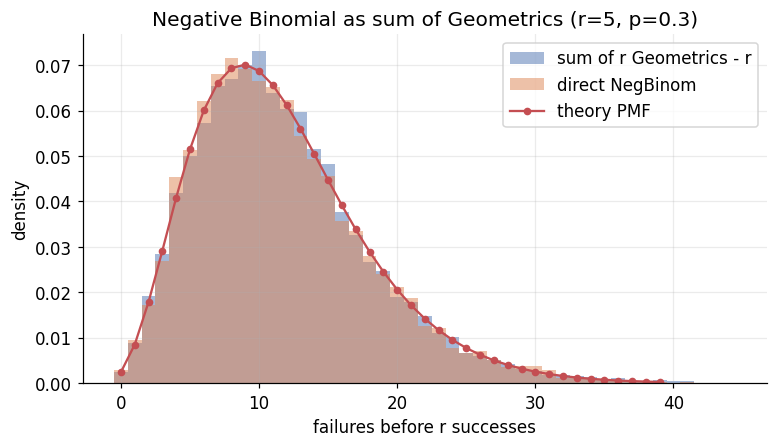

sum-of-geometrics mean 11.692   theory 11.667


In [14]:
# Negative Binomial as a SUM OF GEOMETRICS (vectorized): sum r geometrics, subtract r.
r, p_nb = 5, 0.3
sum_geo = rng.geometric(p_nb, size=(10000, r)).sum(axis=1) - r
direct = stats.nbinom.rvs(r, p_nb, size=10000, random_state=2)
fig, ax = plt.subplots()
bins = np.arange(0, max(sum_geo.max(), direct.max()) + 2) - 0.5
ax.hist(sum_geo, bins=bins, density=True, alpha=0.5, color=BLUE, label='sum of r Geometrics - r')
ax.hist(direct, bins=bins, density=True, alpha=0.5, color=ORANGE, label='direct NegBinom')
xk = np.arange(0, 40)
ax.plot(xk, stats.nbinom.pmf(xk, r, p_nb), 'o-', color=RED, ms=4, label='theory PMF')
ax.set_xlabel('failures before r successes'); ax.set_ylabel('density')
ax.set_title(f'Negative Binomial as sum of Geometrics (r={r}, p={p_nb})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'sum-of-geometrics mean {sum_geo.mean():.3f}   theory {r*(1-p_nb)/p_nb:.3f}')


## Continuous distributions

### Uniform — equal density on $[a,b]$

$f(x)=\dfrac{1}{b-a}$ on $[a,b]$. Laplace's "principle of indifference" and the engine
of all random-number generation.

- **Mean** $\dfrac{a+b}{2}$ · **Variance** $\dfrac{(b-a)^2}{12}$.
- **Probability integral transform:** if $X$ has CDF $F$, then $F(X)\sim\text{Unif}(0,1)$;
  conversely $F^{-1}(U)$ has CDF $F$. This is *why* inverse-CDF sampling works.


In [15]:
a, b = -3.0, 2.0
u = rng.uniform(a, b, 10000)
compare(f'Uniform({a}, {b})', (a+b)/2, (b-a)**2/12, u)
# Chi-square uniformity check: counts in 20 equal bins should match n/20.
counts, _ = np.histogram(u, bins=20, range=(a, b))
chi2_stat = np.sum((counts - len(u)/20)**2 / (len(u)/20))
print(f'  uniformity chi-square = {chi2_stat:.2f}   critical(0.05, df=19) = {stats.chi2.ppf(0.95, 19):.2f}'
      f'   -> {"uniform" if chi2_stat < stats.chi2.ppf(0.95, 19) else "reject"}')


Uniform(-3.0, 2.0)  (n = 10,000)
  mean      theory    -0.5000   sample    -0.4927
  variance  theory     2.0833   sample     2.1146
  uniformity chi-square = 18.58   critical(0.05, df=19) = 30.14   -> uniform


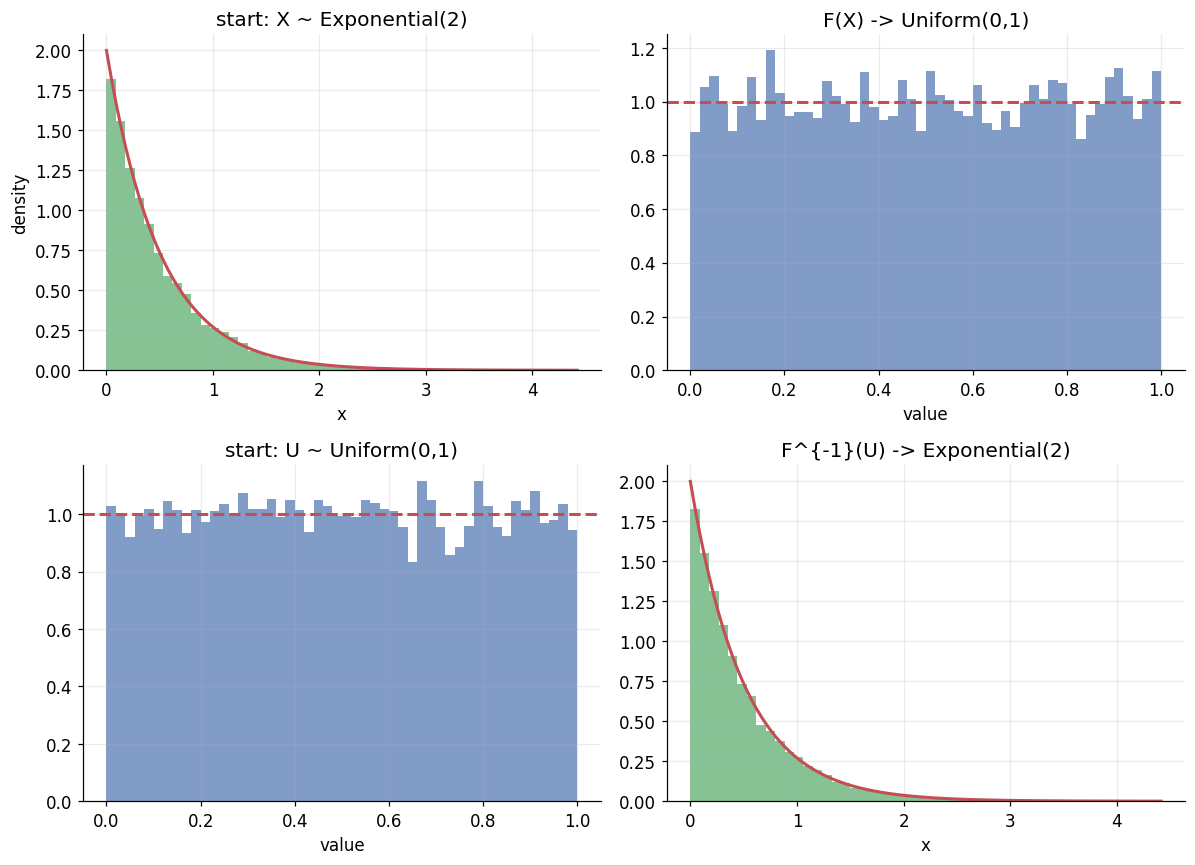

In [16]:
# Probability integral transform, both directions, with Exponential(2).
lam = 2.0
exp_s = rng.exponential(1/lam, 10000)            # X ~ Exp
u_from_x = 1 - np.exp(-lam * exp_s)              # F(X) should be Uniform(0,1)
u_s = rng.uniform(0, 1, 10000)                   # U ~ Unif
x_from_u = -np.log(1 - u_s) / lam               # F^{-1}(U) should be Exponential
fig, ((a1, a2), (a3, a4)) = plt.subplots(2, 2, figsize=(11, 8))
a1.hist(exp_s, bins=50, density=True, alpha=0.7, color=GREEN)
xx = np.linspace(0, exp_s.max(), 200); a1.plot(xx, lam*np.exp(-lam*xx), color=RED, lw=2)
a1.set_title('start: X ~ Exponential(2)'); a1.set_xlabel('x'); a1.set_ylabel('density')
a2.hist(u_from_x, bins=50, density=True, alpha=0.7, color=BLUE)
a2.axhline(1, color=RED, ls='--', lw=2); a2.set_title('F(X) -> Uniform(0,1)'); a2.set_xlabel('value')
a3.hist(u_s, bins=50, density=True, alpha=0.7, color=BLUE)
a3.axhline(1, color=RED, ls='--', lw=2); a3.set_title('start: U ~ Uniform(0,1)'); a3.set_xlabel('value')
a4.hist(x_from_u, bins=50, density=True, alpha=0.7, color=GREEN)
xx = np.linspace(0, x_from_u.max(), 200); a4.plot(xx, lam*np.exp(-lam*xx), color=RED, lw=2)
a4.set_title('F^{-1}(U) -> Exponential(2)'); a4.set_xlabel('x')
plt.tight_layout(); plt.show()


### Normal (Gaussian) — the limit of sums

$f(x)=\dfrac{1}{\sigma\sqrt{2\pi}}\exp\!\big(-\tfrac{(x-\mu)^2}{2\sigma^2}\big)$.
De Moivre (1733) $\to$ Laplace $\to$ Gauss (1809). It appears whenever many small
independent effects add up.

- **Mean** $\mu$ · **Variance** $\sigma^2$ · **68–95–99.7 rule**.
- **Central Limit Theorem:** standardized sample means of *any* finite-variance law
  converge to $\mathcal N(0,1)$.
- **Closed under addition:** $\sum X_i\sim\mathcal N(\sum\mu_i,\sum\sigma_i^2)$.


In [17]:
mu, sigma = 100, 15
x = rng.normal(mu, sigma, 100_000)
compare(f'Normal({mu}, {sigma}^2)', mu, sigma**2, x)
for k in (1, 2, 3):
    frac = np.mean(np.abs(x - mu) <= k*sigma)
    theory = 2*stats.norm.cdf(k) - 1
    print(f'  within {k} sigma: empirical {frac:.4f}   theory {theory:.4f}')
z = (x - mu)/sigma
print(f'  skewness {np.mean(z**3):+.4f} (theory 0)   excess kurtosis {np.mean(z**4)-3:+.4f} (theory 0)')


Normal(100, 15^2)  (n = 100,000)
  mean      theory   100.0000   sample    99.9911
  variance  theory   225.0000   sample   226.1643
  within 1 sigma: empirical 0.6816   theory 0.6827
  within 2 sigma: empirical 0.9543   theory 0.9545
  within 3 sigma: empirical 0.9971   theory 0.9973
  skewness +0.0061 (theory 0)   excess kurtosis +0.0310 (theory 0)


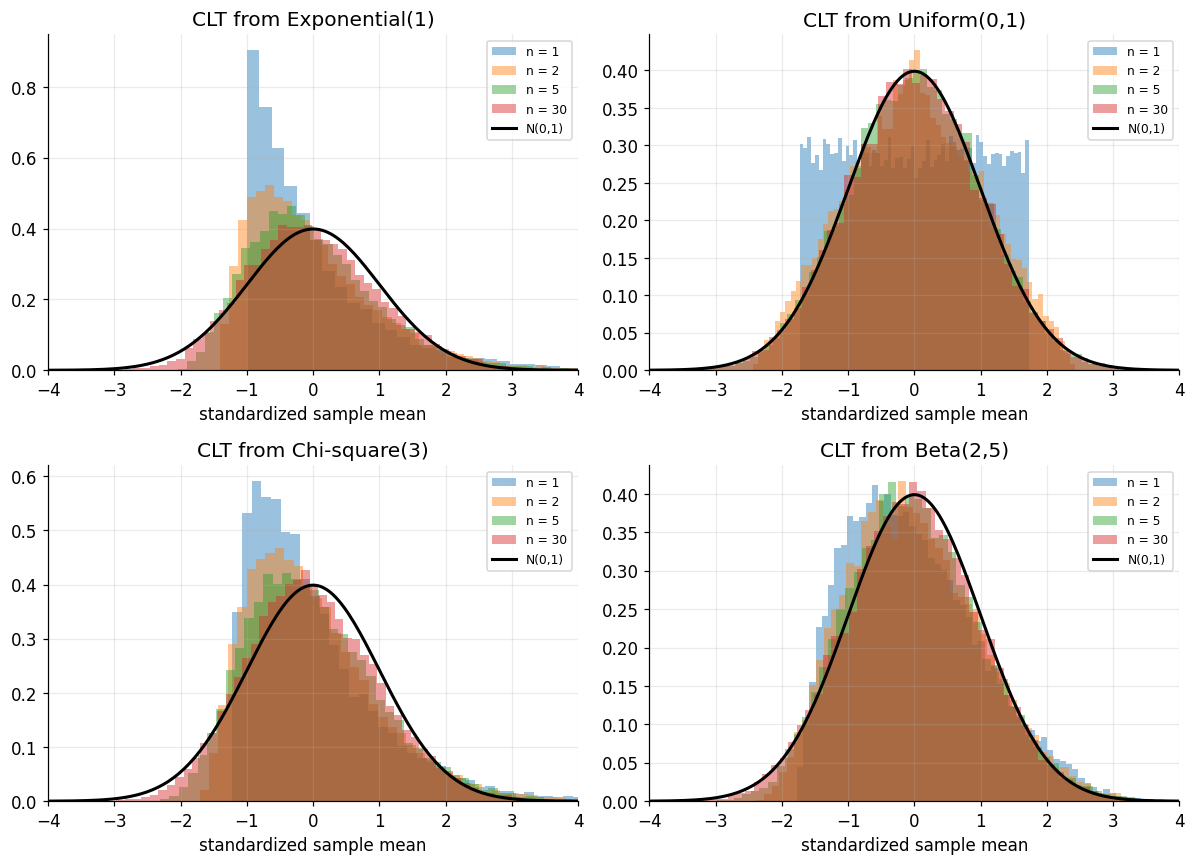

In [18]:
# Central Limit Theorem from four very different starting laws (vectorized).
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
starts = [
    ('Exponential(1)', lambda sz: rng.exponential(1, sz), 1.0, 1.0),
    ('Uniform(0,1)',  lambda sz: rng.uniform(0, 1, sz), 0.5, 1/12),
    ('Chi-square(3)', lambda sz: rng.chisquare(3, sz), 3.0, 6.0),
    ('Beta(2,5)',     lambda sz: rng.beta(2, 5, sz),  2/7, 10/392),
]
for ax, (name, gen, m, v) in zip(axes.flat, starts):
    for n_ in [1, 2, 5, 30]:
        means = gen((20000, n_)).mean(axis=1)
        std = (means - m) / np.sqrt(v / n_)
        ax.hist(std, bins=60, density=True, alpha=0.45, label=f'n = {n_}')
    zz = np.linspace(-4, 4, 200)
    ax.plot(zz, stats.norm.pdf(zz), 'k-', lw=2, label='N(0,1)')
    ax.set_xlim(-4, 4); ax.set_title(f'CLT from {name}'); ax.legend(fontsize=8)
    ax.set_xlabel('standardized sample mean')
plt.tight_layout(); plt.show()


### Exponential — waiting time at constant rate

$f(x)=\lambda e^{-\lambda x}$, $x\ge 0$ (NumPy uses **scale** $=1/\lambda$). Erlang's
telephone-queue distribution.

- **Mean** $1/\lambda$ · **Variance** $1/\lambda^2$ · **Survival** $e^{-\lambda x}$.
- **Memoryless (the only continuous law that is)** — equivalently a *constant hazard*.
- **Poisson link:** inter-arrival times of a rate-$\lambda$ Poisson process.
- **Minimum:** $\min_i X_i\sim\text{Exp}(\sum_i\lambda_i)$.


In [19]:
lam = 2.0
e = rng.exponential(1/lam, 100_000)
compare(f'Exponential(rate={lam})', 1/lam, 1/lam**2, e)
# Memoryless verification (appendix exercise 2b): s=1, t=0.5.
s, t = 1.0, 0.5
surv = e[e > s]
print(f'  P(X > {s}) empirical {np.mean(e > s):.4f}   theory {np.exp(-lam*s):.4f}')
print(f'  P(X > {s+t} | X > {s}) = {np.mean(surv > s + t):.4f}   theory P(X > {t}) = {np.exp(-lam*t):.4f}')


Exponential(rate=2.0)  (n = 100,000)
  mean      theory     0.5000   sample     0.5002
  variance  theory     0.2500   sample     0.2521
  P(X > 1.0) empirical 0.1353   theory 0.1353
  P(X > 1.5 | X > 1.0) = 0.3646   theory P(X > 0.5) = 0.3679


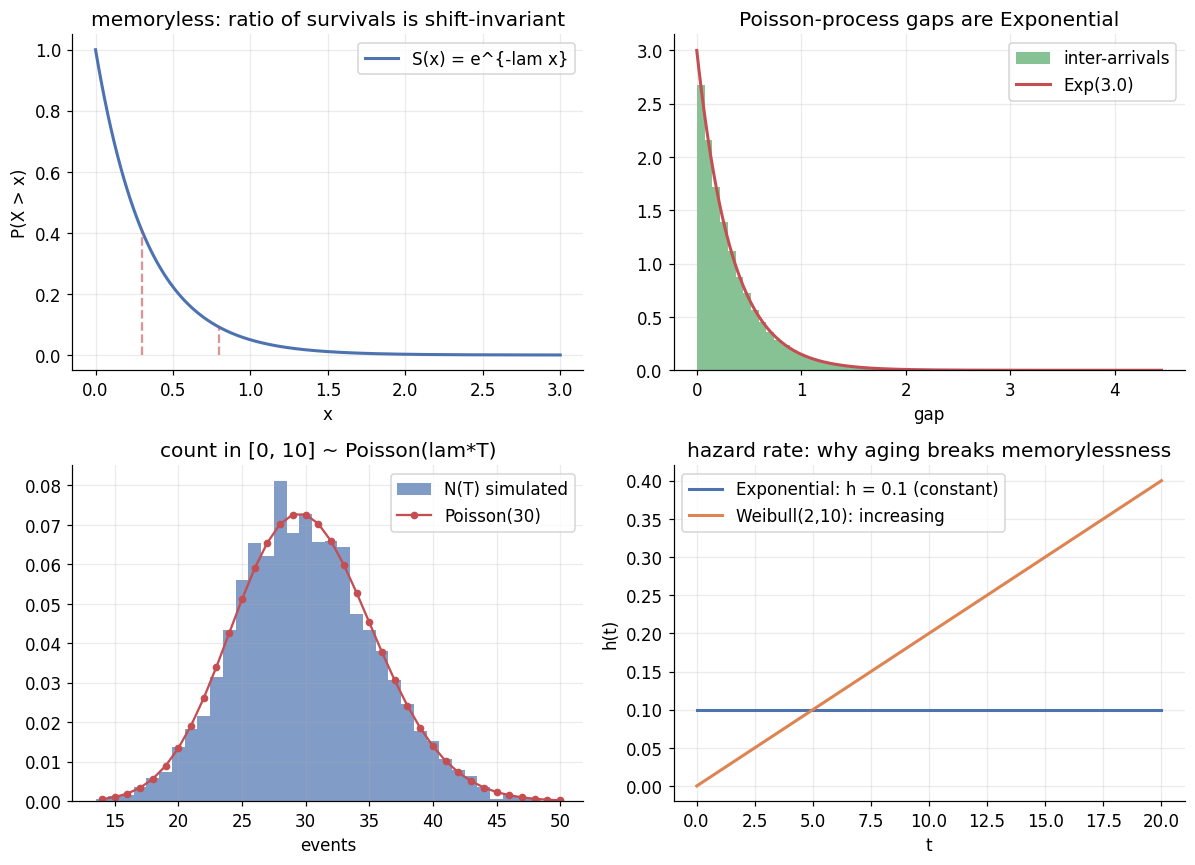

N(T) mean 30.002   theory lambda*T = 30.0   (Poisson => mean = var = 29.507)


In [20]:
# Four faces of the Exponential: memoryless survival, Poisson process inter-arrivals,
# the count N(T) ~ Poisson(lambda T), and the constant-vs-increasing hazard contrast.
lam, T = 3.0, 10.0
fig, ((a1, a2), (a3, a4)) = plt.subplots(2, 2, figsize=(11, 8))

# (1) memoryless survival: S(s+t)/S(s) = S(t)
xx = np.linspace(0, 3, 300)
a1.plot(xx, np.exp(-lam*xx), color=BLUE, lw=2, label='S(x) = e^{-lam x}')
for s0 in (0.3, 0.8):
    a1.plot([s0, s0], [0, np.exp(-lam*s0)], '--', color=RED, alpha=0.6)
a1.set_title('memoryless: ratio of survivals is shift-invariant')
a1.set_xlabel('x'); a1.set_ylabel('P(X > x)'); a1.legend()

# (2) inter-arrival times of a Poisson process are Exponential
K = int(lam*T*3) + 40
inter = rng.exponential(1/lam, size=(3000, K))
a2.hist(inter.ravel(), bins=60, density=True, alpha=0.7, color=GREEN, label='inter-arrivals')
xx = np.linspace(0, inter.ravel().max(), 200)
a2.plot(xx, lam*np.exp(-lam*xx), color=RED, lw=2, label=f'Exp({lam})')
a2.set_title('Poisson-process gaps are Exponential'); a2.set_xlabel('gap'); a2.legend()

# (3) count in [0, T] is Poisson(lambda T)
arrivals = np.cumsum(inter, axis=1)
counts = (arrivals <= T).sum(axis=1)
kk = np.arange(counts.min(), counts.max() + 1)
a3.hist(counts, bins=kk - 0.5, density=True, alpha=0.7, color=BLUE, label='N(T) simulated')
a3.plot(kk, stats.poisson.pmf(kk, lam*T), 'o-', color=RED, ms=4, label=f'Poisson({lam*T:.0f})')
a3.set_title(f'count in [0, {T:.0f}] ~ Poisson(lam*T)'); a3.set_xlabel('events'); a3.legend()

# (4) constant hazard (Exp) vs increasing hazard (Weibull k=2)
tt = np.linspace(0.01, 20, 200)
a4.plot(tt, 0.1*np.ones_like(tt), color=BLUE, lw=2, label='Exponential: h = 0.1 (constant)')
a4.plot(tt, (2/10)*(tt/10)**(2-1), color=ORANGE, lw=2, label='Weibull(2,10): increasing')
a4.set_title('hazard rate: why aging breaks memorylessness')
a4.set_xlabel('t'); a4.set_ylabel('h(t)'); a4.legend()
plt.tight_layout(); plt.show()
print(f'N(T) mean {counts.mean():.3f}   theory lambda*T = {lam*T:.1f}   (Poisson => mean = var = {counts.var():.3f})')


In [21]:
# Minimum of independent exponentials ~ Exp(sum of rates); which fails first ~ rate share.
rates = np.array([1.0, 0.5, 2.0])
times = rng.exponential(1/rates, size=(10000, 3))   # scale broadcasts per column
mins = times.min(axis=1)
first = times.argmin(axis=1)
total = rates.sum()
print(f'rates {rates.tolist()}  ->  min ~ Exp({total})')
print(f'  mean time to first event: sample {mins.mean():.4f}   theory 1/sum = {1/total:.4f}')
for i, rt in enumerate(rates):
    print(f'  P(component {i+1} fails first): sample {np.mean(first == i):.3f}   theory {rt/total:.3f}')


rates [1.0, 0.5, 2.0]  ->  min ~ Exp(3.5)
  mean time to first event: sample 0.2849   theory 1/sum = 0.2857
  P(component 1 fails first): sample 0.285   theory 0.286
  P(component 2 fails first): sample 0.144   theory 0.143
  P(component 3 fails first): sample 0.571   theory 0.571


### Gamma — sum of exponentials / flexible positive law

$f(x)=\dfrac{\beta^\alpha}{\Gamma(\alpha)}x^{\alpha-1}e^{-\beta x}$ (shape $\alpha$,
rate $\beta$; **SciPy uses scale $=1/\beta$**).

- **Mean** $\alpha/\beta$ · **Variance** $\alpha/\beta^2$.
- **Special cases:** $\alpha=1$ is Exponential; $\alpha=k/2,\beta=1/2$ is $\chi^2_k$.
- **Sum of exponentials:** $\sum_{i=1}^n\text{Exp}(\beta)\sim\text{Gamma}(n,\beta)$.
- $\Gamma(n)=(n-1)!$ for integers; $\Gamma(1/2)=\sqrt\pi$.


In [22]:
alpha, beta = 5, 2          # shape, rate
gs = stats.gamma.rvs(a=alpha, scale=1/beta, size=10000, random_state=418)
compare(f'Gamma(shape={alpha}, rate={beta})', alpha/beta, alpha/beta**2, gs)
print('  Gamma(n) = (n-1)! for integers:')
for nn in range(1, 7):
    print(f'    Gamma({nn}) = {gamma_fn(nn):.0f} = {nn-1}!')


Gamma(shape=5, rate=2)  (n = 10,000)
  mean      theory     2.5000   sample     2.4867
  variance  theory     1.2500   sample     1.2193
  Gamma(n) = (n-1)! for integers:
    Gamma(1) = 1 = 0!
    Gamma(2) = 1 = 1!
    Gamma(3) = 2 = 2!
    Gamma(4) = 6 = 3!
    Gamma(5) = 24 = 4!
    Gamma(6) = 120 = 5!


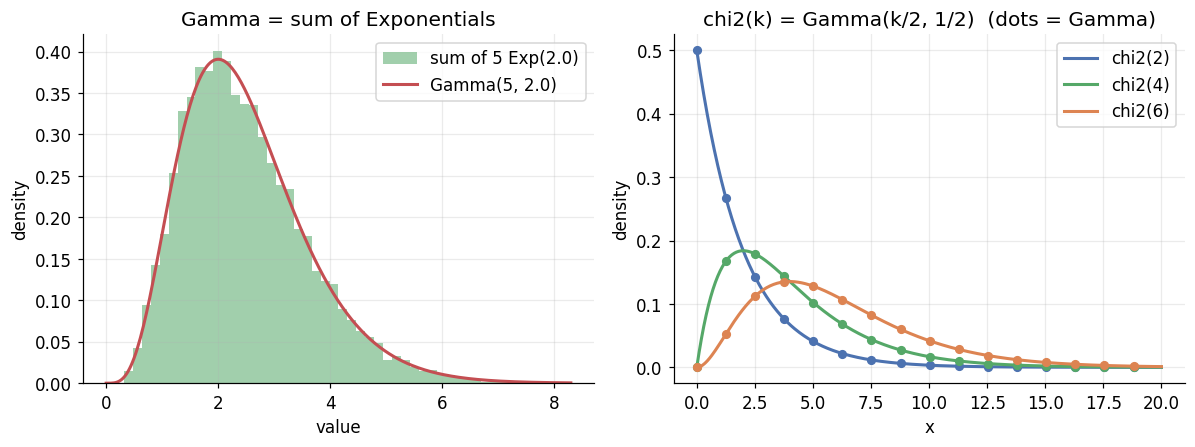

sum-of-exponentials: mean 2.491  theory 2.500 | var 1.252  theory 1.250


In [23]:
# (left) Gamma as a sum of exponentials; (right) chi-square is Gamma(k/2, 1/2).
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
n_exp, lam = 5, 2.0
exp_sum = rng.exponential(1/lam, size=(10000, n_exp)).sum(axis=1)
a1.hist(exp_sum, bins=50, density=True, alpha=0.55, color=GREEN, label=f'sum of {n_exp} Exp({lam})')
xx = np.linspace(0, exp_sum.max(), 300)
a1.plot(xx, stats.gamma.pdf(xx, a=n_exp, scale=1/lam), color=RED, lw=2, label=f'Gamma({n_exp}, {lam})')
a1.set_title('Gamma = sum of Exponentials'); a1.set_xlabel('value'); a1.set_ylabel('density'); a1.legend()
xc = np.linspace(0, 20, 400)
for df, col in zip([2, 4, 6], [BLUE, GREEN, ORANGE]):
    a2.plot(xc, stats.chi2.pdf(xc, df), color=col, lw=2, label=f'chi2({df})')
    a2.plot(xc[::25], stats.gamma.pdf(xc[::25], a=df/2, scale=1/0.5), 'o', color=col, ms=5)
a2.set_title('chi2(k) = Gamma(k/2, 1/2)  (dots = Gamma)')
a2.set_xlabel('x'); a2.set_ylabel('density'); a2.legend()
plt.tight_layout(); plt.show()
print(f'sum-of-exponentials: mean {exp_sum.mean():.3f}  theory {n_exp/lam:.3f} | var {exp_sum.var():.3f}  theory {n_exp/lam**2:.3f}')


### Beta — distribution on $[0,1]$ for proportions

$f(x)=\dfrac{\Gamma(\alpha+\beta)}{\Gamma(\alpha)\Gamma(\beta)}x^{\alpha-1}(1-x)^{\beta-1}$,
$0\le x\le 1$. The conjugate prior for a probability.

- **Mean** $\dfrac{\alpha}{\alpha+\beta}$ · **Variance**
  $\dfrac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$.
- **Shapes:** $\alpha=\beta=1$ is Uniform; $\alpha=\beta=0.5$ is U-shaped; $\alpha=\beta$ symmetric.
- **Order statistics:** the $k$-th smallest of $n$ Uniforms is $\text{Beta}(k,n-k+1)$.
- **Gamma ratio:** $\dfrac{X}{X+Y}\sim\text{Beta}(\alpha,\beta)$ for independent Gammas.


In [24]:
alpha, beta = 2, 5
bs = rng.beta(alpha, beta, 10000)
tv = alpha*beta / ((alpha+beta)**2 * (alpha+beta+1))
compare(f'Beta({alpha}, {beta})', alpha/(alpha+beta), tv, bs)
# Gamma-ratio construction: X/(X+Y) with X~Gamma(a), Y~Gamma(b), same rate.
X = stats.gamma.rvs(a=alpha, scale=1/2, size=10000, random_state=1)
Y = stats.gamma.rvs(a=beta,  scale=1/2, size=10000, random_state=2)
ratio = X / (X + Y)
print(f'  Gamma-ratio X/(X+Y): mean {ratio.mean():.4f}   Beta theory {alpha/(alpha+beta):.4f}')


Beta(2, 5)  (n = 10,000)
  mean      theory     0.2857   sample     0.2847
  variance  theory     0.0255   sample     0.0253
  Gamma-ratio X/(X+Y): mean 0.2857   Beta theory 0.2857


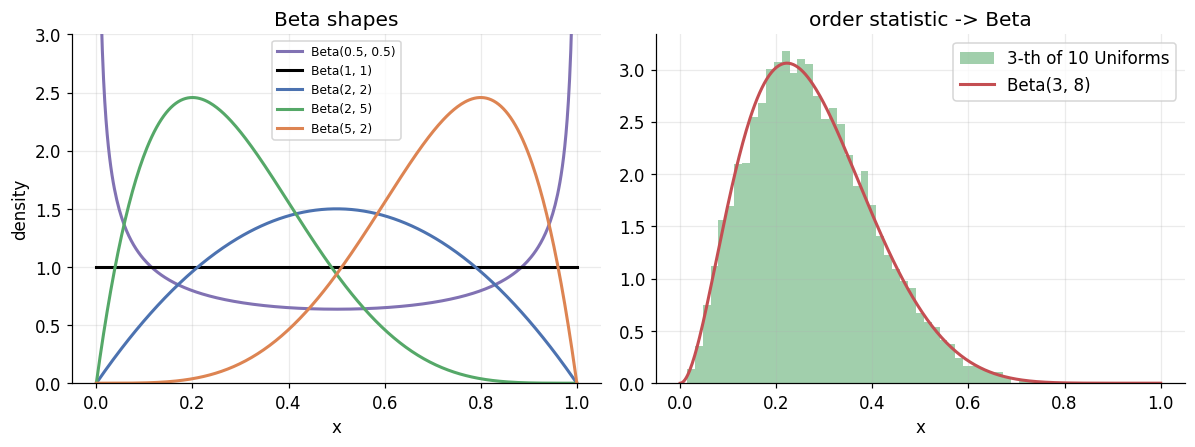

3-th order statistic: sample mean 0.2742   Beta(3,8) mean 0.2727


In [25]:
# (left) the Beta zoo of shapes; (right) k-th order statistic of n Uniforms is Beta(k, n-k+1).
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
xx = np.linspace(0, 1, 400)
for (av, bv), col in zip([(0.5, 0.5), (1, 1), (2, 2), (2, 5), (5, 2)],
                         [PURPLE, 'k', BLUE, GREEN, ORANGE]):
    a1.plot(xx, stats.beta.pdf(xx, av, bv), color=col, lw=2, label=f'Beta({av}, {bv})')
a1.set_ylim(0, 3); a1.set_title('Beta shapes'); a1.set_xlabel('x'); a1.set_ylabel('density'); a1.legend(fontsize=8)
n_o, k_o = 10, 3
order = np.sort(rng.uniform(0, 1, size=(10000, n_o)), axis=1)[:, k_o - 1]
a2.hist(order, bins=50, density=True, alpha=0.55, color=GREEN, label=f'{k_o}-th of {n_o} Uniforms')
a2.plot(xx, stats.beta.pdf(xx, k_o, n_o - k_o + 1), color=RED, lw=2, label=f'Beta({k_o}, {n_o-k_o+1})')
a2.set_title('order statistic -> Beta'); a2.set_xlabel('x'); a2.legend()
plt.tight_layout(); plt.show()
print(f'{k_o}-th order statistic: sample mean {order.mean():.4f}   Beta({k_o},{n_o-k_o+1}) mean {k_o/(n_o+1):.4f}')


## Distributions of statistical inference

### Student's $t$ — small-sample means with unknown variance

$T\sim t(\nu)$ has heavier tails than the Normal. Gosset ("Student") at Guinness, 1908.

- **Mean** $0$ ($\nu>1$) · **Variance** $\dfrac{\nu}{\nu-2}$ ($\nu>2$); $\nu=1$ is Cauchy.
- **Construction:** $T=\dfrac{Z}{\sqrt{V/\nu}}$ with $Z\sim\mathcal N(0,1)$, $V\sim\chi^2_\nu$.
- **Limit:** $t(\nu)\to\mathcal N(0,1)$ as $\nu\to\infty$.
- In practice $T=\dfrac{\bar X-\mu}{S/\sqrt n}\sim t(n-1)$.


In [26]:
for df in [1, 2, 5, 30]:
    v = df/(df-2) if df > 2 else float('inf')
    print(f't({df}): theory var {v if df>2 else "infinite"}'
          + ('' if df > 2 else '   (heavy tails: variance not finite)'))
# Construct t(5) from Z and chi-square, compare to direct samples.
df = 5
Z = rng.normal(0, 1, 100_000)
V = rng.chisquare(df, 100_000)
T = Z / np.sqrt(V/df)
print(f'\nt({df}) built as Z/sqrt(V/nu): sample var {T.var():.3f}   theory nu/(nu-2) = {df/(df-2):.3f}')
print(f'  P(|t({df})| > 1.96) = {2*stats.t.sf(1.96, df):.4f}   vs Normal {2*stats.norm.sf(1.96):.4f}  (t heavier)')


t(1): theory var infinite   (heavy tails: variance not finite)
t(2): theory var infinite   (heavy tails: variance not finite)
t(5): theory var 1.6666666666666667
t(30): theory var 1.0714285714285714

t(5) built as Z/sqrt(V/nu): sample var 1.653   theory nu/(nu-2) = 1.667
  P(|t(5)| > 1.96) = 0.1073   vs Normal 0.0500  (t heavier)


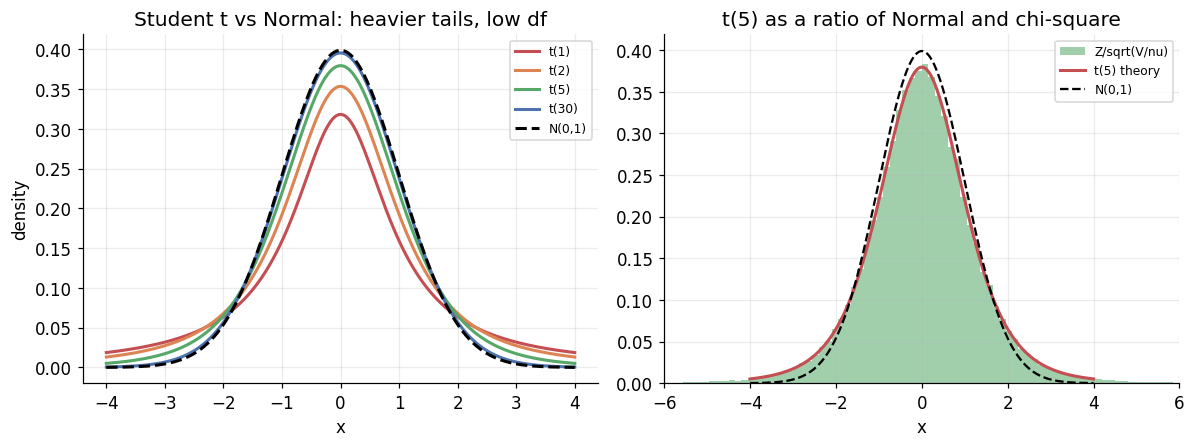

In [27]:
# (left) t PDFs vs Normal; (right) constructed t(5) histogram vs theory.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
xx = np.linspace(-4, 4, 400)
for df, col in zip([1, 2, 5, 30], [RED, ORANGE, GREEN, BLUE]):
    a1.plot(xx, stats.t.pdf(xx, df), color=col, lw=2, label=f't({df})')
a1.plot(xx, stats.norm.pdf(xx), 'k--', lw=2, label='N(0,1)')
a1.set_title('Student t vs Normal: heavier tails, low df'); a1.set_xlabel('x'); a1.set_ylabel('density'); a1.legend(fontsize=8)
a2.hist(T, bins=80, range=(-6, 6), density=True, alpha=0.55, color=GREEN, label='Z/sqrt(V/nu)')
a2.plot(xx, stats.t.pdf(xx, 5), color=RED, lw=2, label='t(5) theory')
a2.plot(xx, stats.norm.pdf(xx), 'k--', lw=1.5, label='N(0,1)')
a2.set_xlim(-6, 6); a2.set_title('t(5) as a ratio of Normal and chi-square'); a2.set_xlabel('x'); a2.legend(fontsize=8)
plt.tight_layout(); plt.show()


### Chi-square — sum of squared standard Normals

$X=\sum_{i=1}^k Z_i^2\sim\chi^2_k$, $Z_i\sim\mathcal N(0,1)$.

- **Mean** $k$ · **Variance** $2k$ · $\chi^2_k=\text{Gamma}(k/2,1/2)$.
- **Additivity:** $\chi^2_{k_1}+\chi^2_{k_2}\sim\chi^2_{k_1+k_2}$.
- Powers goodness-of-fit and variance inference.


In [28]:
df = 5
chi = (rng.normal(0, 1, size=(10000, df))**2).sum(axis=1)   # sum of df squared N(0,1)
compare(f'chi-square({df}) as sum of squared Normals', df, 2*df, chi)
# additivity
k1, k2 = 3, 4
add = rng.chisquare(k1, 10000) + rng.chisquare(k2, 10000)
print(f'  chi2({k1}) + chi2({k2}): sample mean {add.mean():.3f}   chi2({k1+k2}) mean {k1+k2}')


chi-square(5) as sum of squared Normals  (n = 10,000)
  mean      theory     5.0000   sample     4.9602
  variance  theory    10.0000   sample     9.6448
  chi2(3) + chi2(4): sample mean 6.941   chi2(7) mean 7


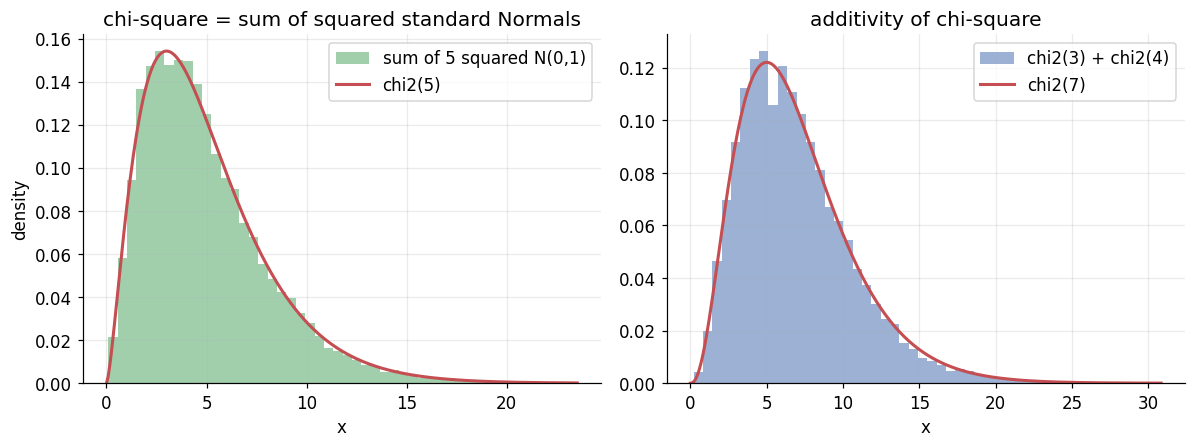

In [29]:
# (left) chi-square as sum of squared Normals; (right) additivity.
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.hist(chi, bins=50, density=True, alpha=0.55, color=GREEN, label=f'sum of {df} squared N(0,1)')
xx = np.linspace(0, chi.max(), 300)
a1.plot(xx, stats.chi2.pdf(xx, df), color=RED, lw=2, label=f'chi2({df})')
a1.set_title('chi-square = sum of squared standard Normals')
a1.set_xlabel('x'); a1.set_ylabel('density'); a1.legend()
a2.hist(add, bins=50, density=True, alpha=0.55, color=BLUE, label=f'chi2({k1}) + chi2({k2})')
xx = np.linspace(0, add.max(), 300)
a2.plot(xx, stats.chi2.pdf(xx, k1+k2), color=RED, lw=2, label=f'chi2({k1+k2})')
a2.set_title('additivity of chi-square'); a2.set_xlabel('x'); a2.legend()
plt.tight_layout(); plt.show()


### $F$ — ratio of two scaled chi-squares

$F=\dfrac{X_1/d_1}{X_2/d_2}\sim F(d_1,d_2)$ with $X_i\sim\chi^2_{d_i}$. Fisher's ANOVA
statistic — between-group vs. within-group variation.

- **Mean** $\dfrac{d_2}{d_2-2}$ ($d_2>2$).
- **$t^2=F(1,\nu)$:** the square of a $t(\nu)$ is $F(1,\nu)$ — the bridge between the
  one-coefficient $t$-test and the $F$-test.


In [30]:
d1, d2 = 5, 10
fr = (rng.chisquare(d1, 10000)/d1) / (rng.chisquare(d2, 10000)/d2)
print(f'F({d1},{d2}) as ratio of scaled chi-squares: sample mean {fr.mean():.4f}   theory d2/(d2-2) = {d2/(d2-2):.4f}')
# t^2 = F(1, df)
df = 10
t2 = stats.t.rvs(df, size=10000, random_state=418)**2
print(f't({df})^2 vs F(1,{df}): t^2 mean {t2.mean():.3f}   F(1,{df}) mean {df/(df-2):.3f}  (both d2/(d2-2))')


F(5,10) as ratio of scaled chi-squares: sample mean 1.2569   theory d2/(d2-2) = 1.2500
t(10)^2 vs F(1,10): t^2 mean 1.261   F(1,10) mean 1.250  (both d2/(d2-2))


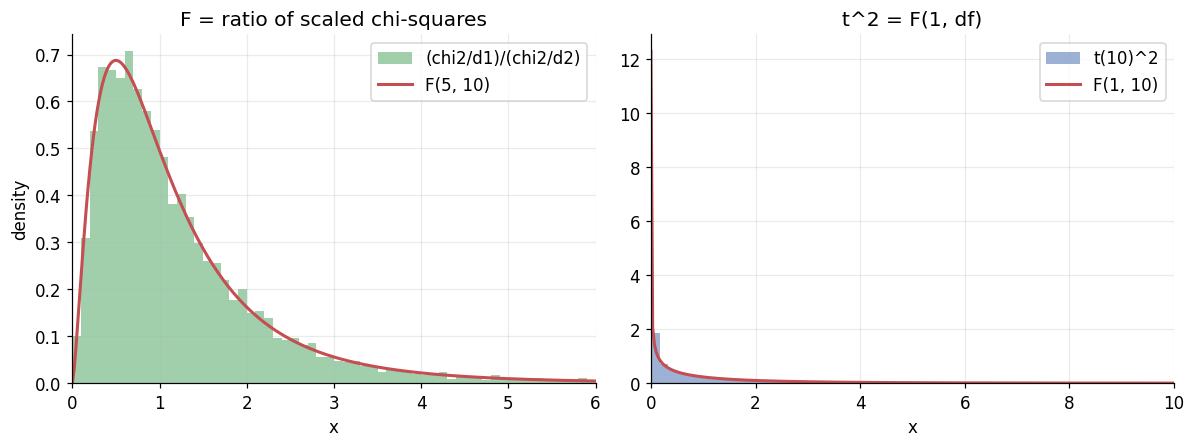

In [31]:
# (left) F as ratio of scaled chi-squares; (right) t^2 = F(1, df).
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
a1.hist(fr, bins=60, range=(0, 6), density=True, alpha=0.55, color=GREEN, label='(chi2/d1)/(chi2/d2)')
xx = np.linspace(0.001, 6, 300)
a1.plot(xx, stats.f.pdf(xx, d1, d2), color=RED, lw=2, label=f'F({d1}, {d2})')
a1.set_xlim(0, 6); a1.set_title('F = ratio of scaled chi-squares')
a1.set_xlabel('x'); a1.set_ylabel('density'); a1.legend()
a2.hist(t2, bins=60, range=(0, 10), density=True, alpha=0.55, color=BLUE, label=f't({df})^2')
xx = np.linspace(0.001, 10, 300)
a2.plot(xx, stats.f.pdf(xx, 1, df), color=RED, lw=2, label=f'F(1, {df})')
a2.set_xlim(0, 10); a2.set_title('t^2 = F(1, df)'); a2.set_xlabel('x'); a2.legend()
plt.tight_layout(); plt.show()


## The family tree: how the distributions connect

Everything above is one web of relationships. The table collects the ones we
*demonstrated by simulation*:

| relationship | type | shown in |
|--------------|------|----------|
| $\sum_{i=1}^n\text{Bernoulli}(p)=\text{Binomial}(n,p)$ | sum | Bernoulli / Binomial |
| $\text{Binomial}(n,p)\to\mathcal N(np,np(1-p))$ | limit (De Moivre–Laplace) | Binomial |
| $\text{Binomial}(n,\lambda/n)\to\text{Poisson}(\lambda)$ | limit | Poisson |
| $\sum_{i=1}^r\text{Geom}(p)-r=\text{NegBin}(r,p)$ | sum | Negative Binomial |
| $F(X)\sim\text{Unif}(0,1)$, $F^{-1}(U)$ has CDF $F$ | transform | Uniform |
| $\bar X$ of any finite-var law $\to\mathcal N$ | limit (CLT) | Normal |
| inter-arrivals of Poisson process $=\text{Exp}(\lambda)$ | construction | Exponential |
| $\min_i\text{Exp}(\lambda_i)=\text{Exp}(\sum\lambda_i)$ | min | Exponential |
| $\sum_{i=1}^n\text{Exp}(\beta)=\text{Gamma}(n,\beta)$ | sum | Gamma |
| $\chi^2_k=\text{Gamma}(k/2,1/2)$ | special case | Gamma |
| $U_{(k)}=\text{Beta}(k,n-k+1)$ | order statistic | Beta |
| $X/(X+Y)=\text{Beta}(\alpha,\beta)$ for Gammas | transform | Beta |
| $Z/\sqrt{V/\nu}=t(\nu)$ | construction | Student $t$ |
| $\sum_{i=1}^k Z_i^2=\chi^2_k$ | sum of squares | Chi-square |
| $(\chi^2_{d_1}/d_1)/(\chi^2_{d_2}/d_2)=F(d_1,d_2)$, $t^2=F(1,\nu)$ | ratio | $F$ |

### Choosing a distribution
- **Counts:** Binomial (fixed trials), Poisson (rare events, mean$=$var), Negative
  Binomial (overdispersed, var$>$mean), Geometric (trials-to-first-success).
- **Continuous:** Normal (sums/errors), Exponential (constant-hazard waits), Gamma
  (positive skew / summed waits), Beta (proportions in $[0,1]$), Uniform (bounded
  ignorance, simulation engine).
- **Inference:** $t$ (small-sample means), $\chi^2$ (variance / goodness-of-fit), $F$
  (comparing variances, ANOVA, regression).

> **Parameterization traps.** Exponential/Gamma: NumPy & SciPy take **scale** $=1/$rate.
> Geometric: SciPy/NumPy count **trials** (support starts at 1), not failures. Always
> check before trusting a number.


## Exercises

Work each before expanding the solution. Both mirror the appendix's practice problems.


**Exercise 1 (Poisson limit, quantified).** The Poisson-limit theorem says
$\text{Binomial}(n,4/n)\to\text{Poisson}(4)$. Simulate $n\in\{10,50,200,1000\}$ with
10,000 draws each, and run a **chi-square goodness-of-fit test** of each Binomial sample
against $\text{Poisson}(4)$. How does the $p$-value move with $n$?


In [32]:
# Solution 1.
lam, n_samples = 4, 10000
gx = np.random.default_rng(42)        # match the appendix's seed for comparable numbers
print(f"{'distribution':<26}{'chi2':>10}{'p-value':>11}   verdict")
print('-'*62)
for n_ in [10, 50, 200, 1000, None]:
    if n_ is None:
        samp = gx.poisson(lam, n_samples); name = 'Poisson(4)'
    else:
        samp = gx.binomial(n_, lam/n_, n_samples); name = f'Binomial({n_}, 4/{n_})'
    observed = np.array([np.sum(samp == k) for k in range(11)] + [np.sum(samp >= 11)], float)
    expected = np.array([stats.poisson.pmf(k, lam) for k in range(11)]
                        + [stats.poisson.sf(10, lam)]) * n_samples
    # pool bins with expected < 5 (chi-square requirement)
    oc, ec, oa, ea = [], [], 0.0, 0.0
    for o, e in zip(observed, expected):
        oa += o; ea += e
        if ea >= 5:
            oc.append(oa); ec.append(ea); oa = ea = 0.0
    if ea > 0:
        oc[-1] += oa; ec[-1] += ea
    chi2_stat, pval = stats.chisquare(oc, ec)
    verdict = 'fail to reject' if pval > 0.05 else 'REJECT H0'
    print(f'{name:<26}{chi2_stat:>10.2f}{pval:>11.4f}   {verdict}')
print('\nWith 10,000 draws the test has high power: the Binomial is decisively non-Poisson')
print('for small n, and indistinguishable from Poisson(4) once n reaches a few hundred.')


distribution                    chi2    p-value   verdict
--------------------------------------------------------------
Binomial(10, 4/10)            912.77     0.0000   REJECT H0
Binomial(50, 4/50)             39.26     0.0000   REJECT H0
Binomial(200, 4/200)           18.08     0.0797   fail to reject
Binomial(1000, 4/1000)          8.59     0.6599   fail to reject
Poisson(4)                      7.25     0.7785   fail to reject

With 10,000 draws the test has high power: the Binomial is decisively non-Poisson
for small n, and indistinguishable from Poisson(4) once n reaches a few hundred.


**Exercise 2 (memorylessness, two ways).** Verify $P(X>s+t\mid X>s)=P(X>t)$ for the
**Exponential** ($\lambda=2$, $s=1,t=0.5$) and its discrete twin the **Geometric**
($p=0.3$, $s=3,t=2$). Confirm both match the closed form.


In [33]:
# Solution 2.
gx = np.random.default_rng(42)
# Exponential (rate=2): NumPy uses scale = 1/rate.
lam, s, t = 2, 1.0, 0.5
e = gx.exponential(1/lam, 100_000)
cond_e = np.mean(e[e > s] > s + t)
print(f'Exponential(rate={lam}):  P(X>{s+t}|X>{s}) = {cond_e:.4f}   theory e^(-lam t) = {np.exp(-lam*t):.4f}')
# Geometric (trials convention, support 1,2,...): survival (1-p)^k.
p, sg, tg = 0.3, 3, 2
g = gx.geometric(p, 100_000)
cond_g = np.mean(g[g > sg] > sg + tg)
print(f'Geometric(p={p}):        P(X>{sg+tg}|X>{sg}) = {cond_g:.4f}   theory (1-p)^t = {(1-p)**tg:.4f}')
print('\nBoth conditional probabilities ignore the elapsed wait -- the defining property,')
print('equivalent to a constant hazard rate. Aging processes (Weibull, Gamma) lack it.')


Exponential(rate=2):  P(X>1.5|X>1.0) = 0.3700   theory e^(-lam t) = 0.3679
Geometric(p=0.3):        P(X>5|X>3) = 0.4894   theory (1-p)^t = 0.4900

Both conditional probabilities ignore the elapsed wait -- the defining property,
equivalent to a constant hazard rate. Aging processes (Weibull, Gamma) lack it.
